In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

TARGET_GENDERS = ["M", "F"]
colors = ["#7f8c8d", "#2ca02c", "#1f77b4", "#ff7f0e", "#d62728"]

sns.set_style("whitegrid")

In [2]:
column_names = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 
                'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

sources = {
    'Cleveland_USA': 'processed.cleveland.data',
    'Hungary_EU': 'processed.hungarian.data',
    'Switzerland_EU': 'processed.switzerland.data',
    'VA_USA': 'processed.va.data'
}


all_dfs = []
# na_values="?" -) chybějící data -) NaN)
for name, path in sources.items():
    df = pd.read_csv(path, names=column_names, na_values="?")
    df['source'] = name
    all_dfs.append(df)

df_all = pd.concat(all_dfs, ignore_index=True)

df_all['target_text'] = df_all['target'].apply(lambda x: 'Heart Disease' if x > 0 else 'Healthy')
df_all['sex_text'] = df_all['sex'].map({1.0: 'Male', 0.0: 'Female'})

print(f"Celkový počet pacientů v realitě: {len(df_all)}")
df_all.head()

Celkový počet pacientů v realitě: 920


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,source,target_text,sex_text
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0,Cleveland_USA,Healthy,Male
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2,Cleveland_USA,Heart Disease,Male
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1,Cleveland_USA,Heart Disease,Male
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0,Cleveland_USA,Healthy,Male
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0,Cleveland_USA,Healthy,Female


In [3]:
# převod 0-4 na zdráv vs nemocný
df_all['target_text'] = df_all['target'].apply(lambda x: 'Heart Disease' if x > 0 else 'Healthy')

df_all['sex_text'] = df_all['sex'].map({1.0: 'Male', 0.0: 'Female'})

print("DISTRIBUCE POHLAVÍ")
sex_dist = df_all['sex_text'].value_counts(normalize=True) * 100
print(sex_dist.round(1))

print("\nCELKOVÝ VÝSKYT ONEMOCNĚNÍ")
target_dist = df_all['target_text'].value_counts(normalize=True) * 100
print(target_dist.round(1))

print("\nPOHLAVÍ A NEMOCI")
cross_dist = pd.crosstab(df_all['sex_text'], df_all['target_text'], normalize='index') * 100
print(cross_dist.round(1))

DISTRIBUCE POHLAVÍ
sex_text
Male      78.9
Female    21.1
Name: proportion, dtype: float64

CELKOVÝ VÝSKYT ONEMOCNĚNÍ
target_text
Heart Disease    55.3
Healthy          44.7
Name: proportion, dtype: float64

POHLAVÍ A NEMOCI
target_text  Healthy  Heart Disease
sex_text                           
Female          74.2           25.8
Male            36.8           63.2


In [4]:
# načtení zero shot dat

def load_heart_data(model_name):
    model_batches = []
    for i in range(1, 6):
        filename = f"zero shot/{model_name}/heart_{i}.csv"
        df = pd.read_csv(filename)
        df.columns = [c.lower().strip() for c in df.columns]
        df['SEX_CLEAN'] = df['sex'].astype(str).str.upper().str[0]
        df["ITERATION"] = f"Batch {i}"
        
        model_batches.append(df)
            
    combined = pd.concat(model_batches, ignore_index=True)
    original_len = len(combined)
    combined = combined.drop_duplicates(subset=column_names)
    
    print(f"{model_name.upper()}: Načteno {len(combined)} unikátních záznamů (odstraněno {original_len - len(combined)} duplicit).")
    return combined

df_claude = load_heart_data("claude")
df_gpt = load_heart_data("gpt")
df_gemini = load_heart_data("gemini")
df_grok = load_heart_data("grok")

CLAUDE: Načteno 917 unikátních záznamů (odstraněno 420 duplicit).
GPT: Načteno 449 unikátních záznamů (odstraněno 62 duplicit).
GEMINI: Načteno 409 unikátních záznamů (odstraněno 1934 duplicit).
GROK: Načteno 675 unikátních záznamů (odstraněno 41 duplicit).


In [5]:
def get_data_yield(df_list, names):
    yield_data = []
    for df, name in zip(df_list, names):
        total_rows = len(df)
        batches = df['ITERATION'].value_counts().sort_index()
        
        yield_data.append({
            "Model": name,
            "total": total_rows,
            "mean v iteraci": total_rows / 5,
            "min v iteraci": batches.min(),
            "max v iteraci": batches.max()
        })
    
    return pd.DataFrame(yield_data).set_index("Model")

model_dfs = [df_claude, df_gpt, df_gemini, df_grok]
model_names = ["Claude", "GPT", "Gemini", "Grok"]

yield_df = get_data_yield(model_dfs, model_names)

print("Přehled zero shot dat")
print(yield_df)

Přehled zero shot dat
        total  mean v iteraci  min v iteraci  max v iteraci
Model                                                      
Claude    917           183.4            130            271
GPT       449            89.8             44            116
Gemini    409            81.8             37            144
Grok      675           135.0             93            170


In [6]:
# rozložení pohlaví

def get_sex_stats(df):
    return df['SEX_CLEAN'].value_counts(normalize=True) * 100

comparison_sex_zs = pd.DataFrame({
    "Realita": df_all['sex_text'].map({'Male': 'M', 'Female': 'F'}).value_counts(normalize=True) * 100,
    "Claude": get_sex_stats(df_claude),
    "GPT": get_sex_stats(df_gpt),
    "Gemini": get_sex_stats(df_gemini),
    "Grok": get_sex_stats(df_grok)
}).reindex(TARGET_GENDERS).fillna(0)

print(comparison_sex_zs.round(1))

   Realita  Claude   GPT  Gemini  Grok
M     78.9    75.5  59.0    71.9  60.9
F     21.1    24.5  41.0    28.1  39.1


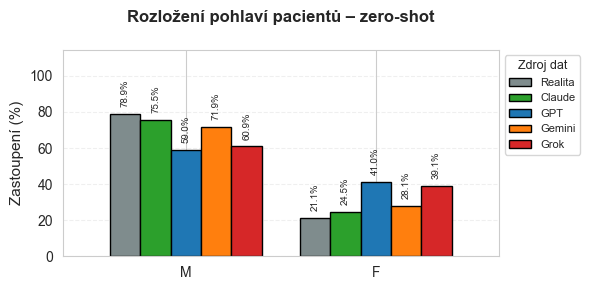

In [7]:
# graf

plt.figure(figsize=(6, 3))

ax = comparison_sex_zs.plot(
    kind="bar", 
    figsize=(6, 3), 
    color=colors, 
    width=0.8, 
    edgecolor="black",
    ax=plt.gca()
)

plt.ylim(0, comparison_sex_zs.values.max() * 1.45)
plt.title("Rozložení pohlaví pacientů – zero-shot", fontsize=12, fontweight="bold", pad=20)
plt.ylabel("Zastoupení (%)", fontsize=11)
plt.xticks(rotation=0, fontsize=10)
plt.yticks(fontsize=10)
plt.legend(title="Zdroj dat", fontsize=8, title_fontsize=9, loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(axis="y", linestyle="--", alpha=0.3)

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f'{height:.1f}%', 
            (p.get_x() + p.get_width() / 2., height), 
            ha='center', va='bottom', 
            fontsize=7, 
            rotation=90, 
            xytext=(0, 5), 
            textcoords='offset points'
        )

plt.tight_layout()
plt.savefig("pohlavi_pacientu_zs.svg")
plt.show()

In [8]:
# pohlaví X nemoc

def get_disease_bias(df, sex_col, target_col):
    m_mask = df[sex_col].astype(str).str.upper().str.startswith('M', na=False)
    f_mask = df[sex_col].astype(str).str.upper().str.startswith('F', na=False)
    
    is_disease = df[target_col].astype(str).str.contains('1|Disease|Positive', case=False, na=False)
    
    m_disease_pct = is_disease[m_mask].mean() * 100
    f_disease_pct = is_disease[f_mask].mean() * 100
    
    return m_disease_pct, f_disease_pct

disease_comp_zs = pd.DataFrame({
    "Realita": get_disease_bias(df_all, 'sex_text', 'target_text'),
    "Claude":  get_disease_bias(df_claude, 'SEX_CLEAN', 'target'),
    "GPT":     get_disease_bias(df_gpt, 'SEX_CLEAN', 'target'),
    "Gemini":  get_disease_bias(df_gemini, 'SEX_CLEAN', 'target'),
    "Grok":    get_disease_bias(df_grok, 'SEX_CLEAN', 'target')
}, index=["Muži: Výskyt nemoci", "Ženy: Výskyt nemoci"]).fillna(0)

print("ASOCIAČNÍ BIAS: VÝSKYT NEMOCI U POHLAVÍ")
print(disease_comp_zs.round(1))

ASOCIAČNÍ BIAS: VÝSKYT NEMOCI U POHLAVÍ
                     Realita  Claude   GPT  Gemini  Grok
Muži: Výskyt nemoci     63.2    59.1  58.5    57.5  51.3
Ženy: Výskyt nemoci     25.8    23.6  23.9    48.7  28.8


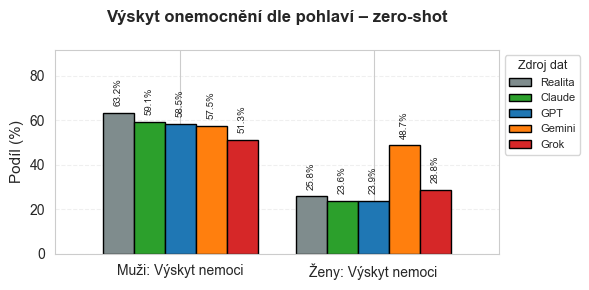

In [9]:
# GRAF

plt.figure(figsize=(6, 3))
ax = disease_comp_zs.plot(
    kind="bar", 
    figsize=(6, 3), 
    color=colors, 
    width=0.8, 
    edgecolor="black",
    ax=plt.gca()
)

plt.ylim(0, disease_comp_zs.values.max() * 1.45)
plt.title("Výskyt onemocnění dle pohlaví – zero-shot", fontsize=12, fontweight="bold", pad=20)
plt.ylabel("Podíl (%)", fontsize=11)
plt.xticks(rotation=0, fontsize=10)
plt.yticks(fontsize=10)
plt.legend(title="Zdroj dat", fontsize=8, title_fontsize=9, loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(axis="y", linestyle="--", alpha=0.3)

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f'{height:.1f}%', 
            (p.get_x() + p.get_width() / 2., height), 
            ha='center', va='bottom', 
            fontsize=7, 
            rotation=90, 
            xytext=(0, 5), 
            textcoords='offset points'
        )

plt.tight_layout()
plt.savefig("onemocneni_pohlavi_zs.svg")
plt.show()

In [10]:
print("\nPrůměrná tepová frekvence v datech:")
print(f"Realita: {df_all['thalach'].mean():.1f}")
print(f"Claude:  {df_claude['thalach'].mean():.1f}")
print(f"GPT:     {df_gpt['thalach'].mean():.1f}")
print(f"Gemini:  {df_gemini['thalach'].mean():.1f}")
print(f"Grok:    {df_grok['thalach'].mean():.1f}")


Průměrná tepová frekvence v datech:
Realita: 137.5
Claude:  145.6
GPT:     152.3
Gemini:  149.7
Grok:    143.5


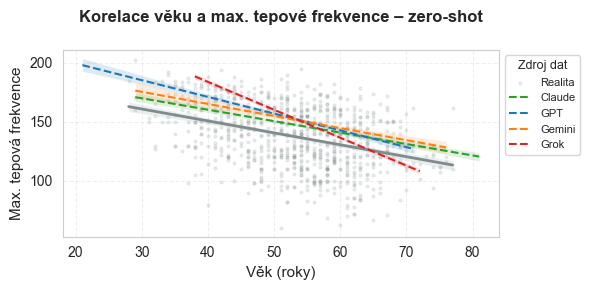

In [11]:
# věk X tepovka


plt.figure(figsize=(6, 3))

sns.regplot(data=df_all, x='age', y='thalach', scatter_kws={'alpha':0.15, 's':4}, 
            color=colors[0], label='Realita', line_kws={'linewidth': 2})

sns.regplot(data=df_claude, x='age', y='thalach', scatter=False, color=colors[1], 
            label='Claude', line_kws={'linewidth': 1.5, 'linestyle': '--'})
sns.regplot(data=df_gpt, x='age', y='thalach', scatter=False, color=colors[2], 
            label='GPT', line_kws={'linewidth': 1.5, 'linestyle': '--'})
sns.regplot(data=df_gemini, x='age', y='thalach', scatter=False, color=colors[3], 
            label='Gemini', line_kws={'linewidth': 1.5, 'linestyle': '--'})
sns.regplot(data=df_grok, x='age', y='thalach', scatter=False, color=colors[4], 
            label='Grok', line_kws={'linewidth': 1.5, 'linestyle': '--'})

plt.title("Korelace věku a max. tepové frekvence – zero-shot", fontsize=12, fontweight="bold", pad=20)
plt.xlabel("Věk (roky)", fontsize=11)
plt.ylabel("Max. tepová frekvence", fontsize=11)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.grid(True, linestyle="--", alpha=0.3)
plt.legend(title="Zdroj dat", fontsize=8, title_fontsize=9, loc='upper left', bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.savefig("korelace_tep_vek_zs.svg")
plt.show()

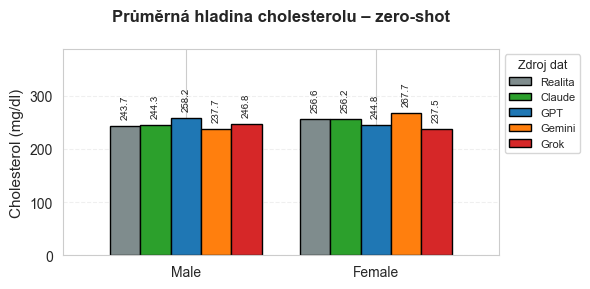

In [12]:
# chol X pohlaví

df_real_chol = df_all[df_all['chol'] > 0].copy()

chol_stats = pd.DataFrame({
    "Realita": df_real_chol.groupby('sex_text')['chol'].mean(),
    "Claude":  df_claude.groupby('SEX_CLEAN')['chol'].mean().rename({'M': 'Male', 'F': 'Female'}),
    "GPT":     df_gpt.groupby('SEX_CLEAN')['chol'].mean().rename({'M': 'Male', 'F': 'Female'}),
    "Gemini":  df_gemini.groupby('SEX_CLEAN')['chol'].mean().rename({'M': 'Male', 'F': 'Female'}),
    "Grok":    df_grok.groupby('SEX_CLEAN')['chol'].mean().rename({'M': 'Male', 'F': 'Female'})
}).reindex(['Male', 'Female'])

# Vykreslení
plt.figure(figsize=(6, 3))

ax = chol_stats.plot(
    kind="bar", 
    figsize=(6, 3), 
    color=colors, 
    width=0.8, 
    edgecolor="black",
    ax=plt.gca()
)

plt.ylim(0, chol_stats.values.max() * 1.45)
plt.title("Průměrná hladina cholesterolu – zero-shot", fontsize=12, fontweight="bold", pad=20)
plt.ylabel("Cholesterol (mg/dl)", fontsize=11)
plt.xticks(rotation=0, fontsize=10)
plt.yticks(fontsize=10)
plt.legend(title="Zdroj dat", fontsize=8, title_fontsize=9, loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(axis="y", linestyle="--", alpha=0.3)

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f'{height:.1f}', 
            (p.get_x() + p.get_width() / 2., height), 
            ha='center', va='bottom', 
            fontsize=7, 
            rotation=90, 
            xytext=(0, 5), 
            textcoords='offset points'
        )

plt.tight_layout()
plt.savefig("cholesterol_pohlavi_zs.svg")
plt.show()

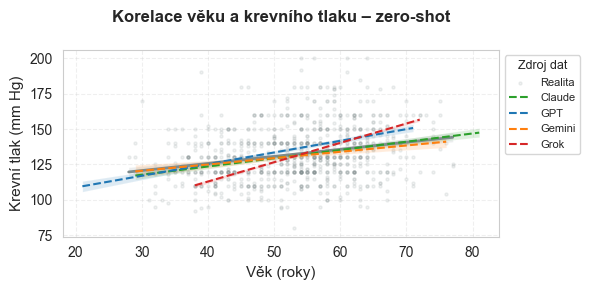

In [13]:
# krevní tlak X věk

plt.figure(figsize=(6, 3))

sns.regplot(data=df_all[df_all['trestbps'] > 0], x='age', y='trestbps', 
            scatter_kws={'alpha':0.12, 's':5}, color=colors[0], label='Realita', 
            line_kws={'linewidth': 2})

sns.regplot(data=df_claude, x='age', y='trestbps', scatter=False, color=colors[1], 
            label='Claude', line_kws={'linewidth': 1.5, 'linestyle': '--'})
sns.regplot(data=df_gpt, x='age', y='trestbps', scatter=False, color=colors[2], 
            label='GPT', line_kws={'linewidth': 1.5, 'linestyle': '--'})
sns.regplot(data=df_gemini, x='age', y='trestbps', scatter=False, color=colors[3], 
            label='Gemini', line_kws={'linewidth': 1.5, 'linestyle': '--'})
sns.regplot(data=df_grok, x='age', y='trestbps', scatter=False, color=colors[4], 
            label='Grok', line_kws={'linewidth': 1.5, 'linestyle': '--'})

plt.title("Korelace věku a krevního tlaku – zero-shot", fontsize=12, fontweight="bold", pad=20)
plt.xlabel("Věk (roky)", fontsize=11)
plt.ylabel("Krevní tlak (mm Hg)", fontsize=11)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.grid(True, linestyle="--", alpha=0.3)
plt.legend(title="Zdroj dat", fontsize=8, title_fontsize=9, loc='upper left', bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.savefig("korelace_tlak_vek_zs.svg")
plt.show()

In [14]:
def get_oldpeak_logic(df, target_col):
    sick_mask = df[target_col].astype(str).str.contains('1|2|3|4|Disease', case=False, na=False)
    
    mean_healthy = df[~sick_mask]['oldpeak'].mean()
    mean_sick = df[sick_mask]['oldpeak'].mean()
    return mean_healthy, mean_sick

oldpeak_comp = pd.DataFrame({
    "Realita": get_oldpeak_logic(df_all, 'target_text'),
    "Claude":  get_oldpeak_logic(df_claude, 'target'),
    "GPT":     get_oldpeak_logic(df_gpt, 'target'),
    "Gemini":  get_oldpeak_logic(df_gemini, 'target'),
    "Grok":    get_oldpeak_logic(df_grok, 'target')
}, index=["Zdraví (Průměr Oldpeak)", "Nemocní (Průměr Oldpeak)"])

print(oldpeak_comp.round(2))

                          Realita  Claude   GPT  Gemini  Grok
Zdraví (Průměr Oldpeak)      0.42    0.52  0.57    1.03  0.55
Nemocní (Průměr Oldpeak)     1.26    1.52  2.40    1.30  2.31


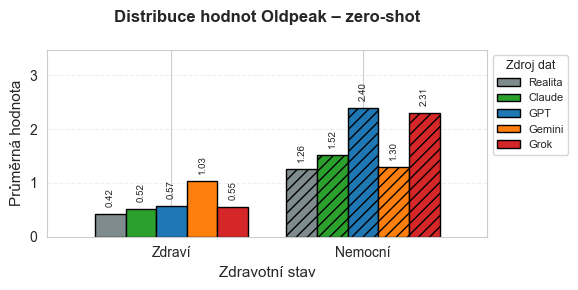

In [15]:
#graf
plt.figure(figsize=(6, 3))

plot_data = oldpeak_comp.copy()
plot_data.index = ["Zdraví", "Nemocní"]

ax = plot_data.plot(
    kind="bar", 
    figsize=(6, 3), 
    color=colors, 
    width=0.8, 
    edgecolor="black",
    ax=plt.gca()
)

plt.ylim(0, plot_data.values.max() * 1.45)
plt.title("Distribuce hodnot Oldpeak – zero-shot", fontsize=12, fontweight="bold", pad=20)
plt.ylabel("Průměrná hodnota", fontsize=11)
plt.xlabel("Zdravotní stav", fontsize=11)
plt.xticks(rotation=0, fontsize=10)
plt.yticks(fontsize=10)
plt.legend(title="Zdroj dat", fontsize=8, title_fontsize=9, loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(axis="y", linestyle="--", alpha=0.3)

for i, p in enumerate(ax.patches):
    if i % 2 != 0:
        p.set_hatch('///')

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f'{height:.2f}', 
            (p.get_x() + p.get_width() / 2., height), 
            ha='center', va='bottom', 
            fontsize=7, 
            rotation=90, 
            xytext=(0, 5), 
            textcoords='offset points'
        )

plt.tight_layout()
plt.savefig("oldpeak_distribuce_zs.svg")
plt.show()

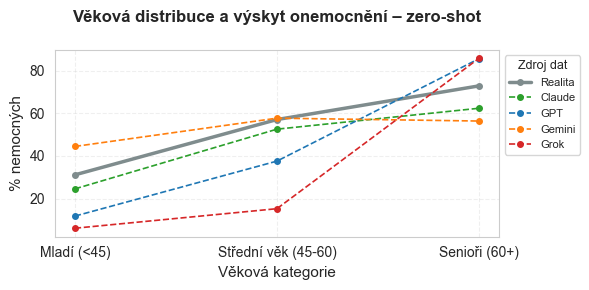

In [16]:
# nemoc X věkové skupiny

bins = [0, 45, 60, 100]
labels = ['Mladí (<45)', 'Střední věk (45-60)', 'Senioři (60+)']

def get_age_risk(df, target_col):
    df_temp = df.copy()
    df_temp['age_group'] = pd.cut(df_temp['age'], bins=bins, labels=labels)
    is_sick = df_temp[target_col].astype(str).str.contains('1|2|3|4|Disease', case=False, na=False)
    return df_temp.groupby('age_group', observed=True)[target_col].apply(lambda x: is_sick[x.index].mean() * 100)

age_risk_comp = pd.DataFrame({
    "Realita": get_age_risk(df_all, 'target_text'),
    "Claude":  get_age_risk(df_claude, 'target'),
    "GPT":     get_age_risk(df_gpt, 'target'),
    "Gemini":  get_age_risk(df_gemini, 'target'),
    "Grok":    get_age_risk(df_grok, 'target')
})

# Vykreslení
plt.figure(figsize=(6, 3))

for i, col in enumerate(age_risk_comp.columns):
    is_real = (col == "Realita")
    linewidth = 2.5 if is_real else 1.2
    linestyle = '-' if is_real else '--'
    
    plt.plot(
        age_risk_comp.index, 
        age_risk_comp[col], 
        label=col, 
        color=colors[i], 
        linewidth=linewidth, 
        linestyle=linestyle, 
        marker='o', 
        markersize=4
    )

plt.title("Věková distribuce a výskyt onemocnění – zero-shot", fontsize=12, fontweight="bold", pad=20)
plt.ylabel("% nemocných", fontsize=11)
plt.xlabel("Věková kategorie", fontsize=11)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(True, linestyle="--", alpha=0.3)
plt.legend(title="Zdroj dat", fontsize=8, title_fontsize=9, loc='upper left', bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.savefig("vek_riziko_zs.svg")
plt.show()

In [17]:
# adv

def load_heart_data_adv(model_name):
    model_batches = []
    for i in range(1, 6):
        filename = f"few shot/{model_name}/heart_adv_{i}.csv"
        
        df = pd.read_csv(filename)
        
        # Sjednocení názvů sloupců (trim a lowercase)
        df.columns = [c.lower().strip() for c in df.columns]
        
        # Čištění pohlaví (vždy na jedno velké písmeno M/F)
        df['SEX_CLEAN'] = df['sex'].astype(str).str.upper().str[0]
        df["ITERATION"] = f"Batch {i}"
        
        model_batches.append(df)
            
    combined = pd.concat(model_batches, ignore_index=True)
    
    original_len = len(combined)
    combined = combined.drop_duplicates(subset=column_names)
    
    print(f"{model_name.upper()} (adv): Načteno {len(combined)} unikátních záznamů (odstraněno {original_len - len(combined)} duplicit).")
    return combined

df_claude_adv = load_heart_data_adv("claude")
df_gpt_adv = load_heart_data_adv("gpt")
df_gemini_adv = load_heart_data_adv("gemini")
df_grok_adv = load_heart_data_adv("grok")

CLAUDE (adv): Načteno 1351 unikátních záznamů (odstraněno 168 duplicit).
GPT (adv): Načteno 503 unikátních záznamů (odstraněno 272 duplicit).
GEMINI (adv): Načteno 604 unikátních záznamů (odstraněno 2242 duplicit).
GROK (adv): Načteno 469 unikátních záznamů (odstraněno 1514 duplicit).


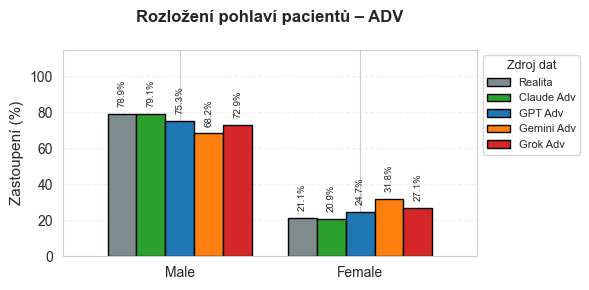

In [18]:
# rozložení pohlaví ADV

def get_sex_stats_adv(df):
    return df['SEX_CLEAN'].value_counts(normalize=True) * 100

sex_comp_adv = pd.DataFrame({
    "Realita": sex_dist, 
    "Claude Adv": get_sex_stats_adv(df_claude_adv).rename({'M': 'Male', 'F': 'Female'}),
    "GPT Adv": get_sex_stats_adv(df_gpt_adv).rename({'M': 'Male', 'F': 'Female'}),
    "Gemini Adv": get_sex_stats_adv(df_gemini_adv).rename({'M': 'Male', 'F': 'Female'}),
    "Grok Adv": get_sex_stats_adv(df_grok_adv).rename({'M': 'Male', 'F': 'Female'})
}).reindex(['Male', 'Female']).fillna(0)

plt.figure(figsize=(6, 3))

ax = sex_comp_adv.plot(
    kind="bar", 
    figsize=(6, 3), 
    color=colors, 
    width=0.8, 
    edgecolor="black",
    ax=plt.gca()
)

plt.ylim(0, sex_comp_adv.values.max() * 1.45)
plt.title("Rozložení pohlaví pacientů – ADV", fontsize=12, fontweight="bold", pad=20)
plt.ylabel("Zastoupení (%)", fontsize=11)
plt.xticks(rotation=0, fontsize=10)
plt.yticks(fontsize=10)
plt.legend(title="Zdroj dat", fontsize=8, title_fontsize=9, loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(axis="y", linestyle="--", alpha=0.3)

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f'{height:.1f}%', 
            (p.get_x() + p.get_width() / 2., height), 
            ha='center', va='bottom', 
            fontsize=7, 
            rotation=90, 
            xytext=(0, 5), 
            textcoords='offset points'
        )

plt.tight_layout()
plt.savefig("pohlavi_pacientu_adv.svg")
plt.show()

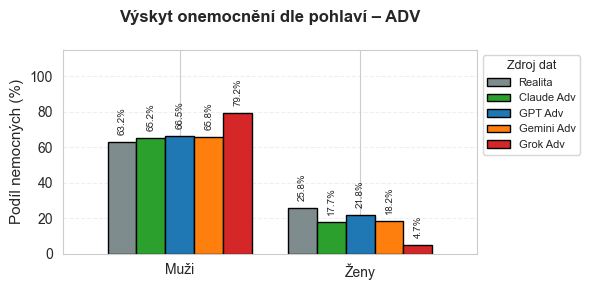

In [19]:
# nemoc X pohlaví ADV

def get_disease_bias_adv(df, sex_col, target_col):
    is_disease = df[target_col].astype(str).str.contains('1|2|3|4|Disease|Positive', case=False, na=False)
    sex_series = df[sex_col].astype(str).str.upper().str[0]
    return is_disease.groupby(sex_series).mean() * 100

disease_comp_adv = pd.DataFrame({
    "Realita": get_disease_bias_adv(df_all, 'sex_text', 'target_text'),
    "Claude Adv":  get_disease_bias_adv(df_claude_adv, 'SEX_CLEAN', 'target'),
    "GPT Adv":     get_disease_bias_adv(df_gpt_adv, 'SEX_CLEAN', 'target'),
    "Gemini Adv":  get_disease_bias_adv(df_gemini_adv, 'SEX_CLEAN', 'target'),
    "Grok Adv":    get_disease_bias_adv(df_grok_adv, 'SEX_CLEAN', 'target')
}).reindex(['M', 'F'])

plt.figure(figsize=(6, 3))

ax = disease_comp_adv.plot(
    kind="bar", 
    figsize=(6, 3), 
    color=colors, 
    width=0.8, 
    edgecolor="black",
    ax=plt.gca()
)

plt.ylim(0, disease_comp_adv.values.max() * 1.45)
plt.title("Výskyt onemocnění dle pohlaví – ADV", fontsize=12, fontweight="bold", pad=20)
plt.ylabel("Podíl nemocných (%)", fontsize=11)
plt.xticks(ticks=[0, 1], labels=["Muži", "Ženy"], rotation=0, fontsize=10)
plt.yticks(fontsize=10)
plt.legend(title="Zdroj dat", fontsize=8, title_fontsize=9, loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(axis="y", linestyle="--", alpha=0.3)

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f'{height:.1f}%', 
            (p.get_x() + p.get_width() / 2., height), 
            ha='center', va='bottom', 
            fontsize=7, 
            rotation=90, 
            xytext=(0, 5), 
            textcoords='offset points'
        )

plt.tight_layout()
plt.savefig("onemocneni_pohlavi_adv.svg")
plt.show()

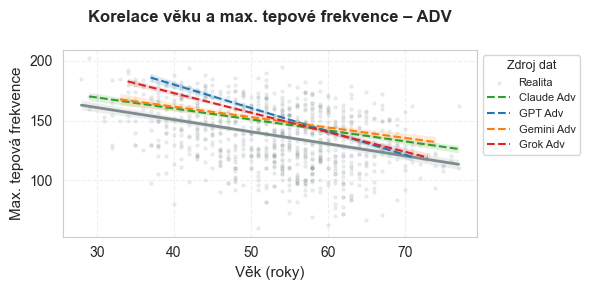

In [20]:
# tepovka X věk ADV

plt.figure(figsize=(6, 3))

sns.regplot(data=df_all, x='age', y='thalach', 
            scatter_kws={'alpha':0.12, 's':5}, color=colors[0], label='Realita', 
            line_kws={'linewidth': 2})

sns.regplot(data=df_claude_adv, x='age', y='thalach', scatter=False, color=colors[1], 
            label='Claude Adv', line_kws={'linewidth': 1.5, 'linestyle': '--'})
sns.regplot(data=df_gpt_adv, x='age', y='thalach', scatter=False, color=colors[2], 
            label='GPT Adv', line_kws={'linewidth': 1.5, 'linestyle': '--'})
sns.regplot(data=df_gemini_adv, x='age', y='thalach', scatter=False, color=colors[3], 
            label='Gemini Adv', line_kws={'linewidth': 1.5, 'linestyle': '--'})
sns.regplot(data=df_grok_adv, x='age', y='thalach', scatter=False, color=colors[4], 
            label='Grok Adv', line_kws={'linewidth': 1.5, 'linestyle': '--'})

plt.title("Korelace věku a max. tepové frekvence – ADV", fontsize=12, fontweight="bold", pad=20)
plt.xlabel("Věk (roky)", fontsize=11)
plt.ylabel("Max. tepová frekvence", fontsize=11)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(True, linestyle="--", alpha=0.3)
plt.legend(title="Zdroj dat", fontsize=8, title_fontsize=9, loc='upper left', bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.savefig("korelace_tep_vek_adv.svg")
plt.show()

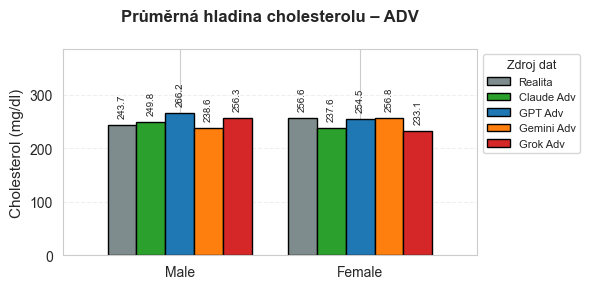

In [21]:
# CHOLESTEROL DLE POHLAVÍ (ADV)

df_real_chol = df_all[df_all['chol'] > 0].copy()

chol_stats_adv = pd.DataFrame({
    "Realita": df_real_chol.groupby('sex_text')['chol'].mean(),
    "Claude Adv":  df_claude_adv.groupby('SEX_CLEAN')['chol'].mean().rename({'M': 'Male', 'F': 'Female'}),
    "GPT Adv":     df_gpt_adv.groupby('SEX_CLEAN')['chol'].mean().rename({'M': 'Male', 'F': 'Female'}),
    "Gemini Adv":  df_gemini_adv.groupby('SEX_CLEAN')['chol'].mean().rename({'M': 'Male', 'F': 'Female'}),
    "Grok Adv":    df_grok_adv.groupby('SEX_CLEAN')['chol'].mean().rename({'M': 'Male', 'F': 'Female'})
}).reindex(['Male', 'Female'])

plt.figure(figsize=(6, 3))

ax = chol_stats_adv.plot(
    kind="bar", 
    figsize=(6, 3), 
    color=colors, 
    width=0.8, 
    edgecolor="black",
    ax=plt.gca()
)

plt.ylim(0, chol_stats_adv.values.max() * 1.45)
plt.title("Průměrná hladina cholesterolu – ADV", fontsize=12, fontweight="bold", pad=20)
plt.ylabel("Cholesterol (mg/dl)", fontsize=11)
plt.xticks(rotation=0, fontsize=10)
plt.yticks(fontsize=10)
plt.legend(title="Zdroj dat", fontsize=8, title_fontsize=9, loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(axis="y", linestyle="--", alpha=0.3)

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f'{height:.1f}', 
            (p.get_x() + p.get_width() / 2., height), 
            ha='center', va='bottom', 
            fontsize=7, 
            rotation=90, 
            xytext=(0, 5), 
            textcoords='offset points'
        )

plt.tight_layout()
plt.savefig("cholesterol_pohlavi_adv.svg")
plt.show()

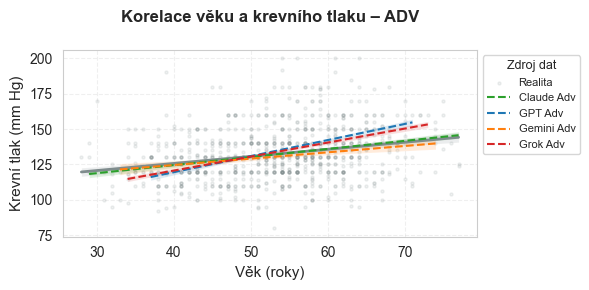

In [22]:
# krevní tlak X věk ADV

plt.figure(figsize=(6, 3))

sns.regplot(data=df_all[df_all['trestbps'] > 0], x='age', y='trestbps', 
            scatter_kws={'alpha':0.12, 's':5}, color=colors[0], label='Realita', 
            line_kws={'linewidth': 2})

sns.regplot(data=df_claude_adv, x='age', y='trestbps', scatter=False, color=colors[1], 
            label='Claude Adv', line_kws={'linewidth': 1.5, 'linestyle': '--'})
sns.regplot(data=df_gpt_adv, x='age', y='trestbps', scatter=False, color=colors[2], 
            label='GPT Adv', line_kws={'linewidth': 1.5, 'linestyle': '--'})
sns.regplot(data=df_gemini_adv, x='age', y='trestbps', scatter=False, color=colors[3], 
            label='Gemini Adv', line_kws={'linewidth': 1.5, 'linestyle': '--'})
sns.regplot(data=df_grok_adv, x='age', y='trestbps', scatter=False, color=colors[4], 
            label='Grok Adv', line_kws={'linewidth': 1.5, 'linestyle': '--'})

plt.title("Korelace věku a krevního tlaku – ADV", fontsize=12, fontweight="bold", pad=20)
plt.xlabel("Věk (roky)", fontsize=11)
plt.ylabel("Krevní tlak (mm Hg)", fontsize=11)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(True, linestyle="--", alpha=0.3)
plt.legend(title="Zdroj dat", fontsize=8, title_fontsize=9, loc='upper left', bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.savefig("korelace_tlak_vek_adv.svg")
plt.show()

In [23]:
# EKG ADV

def get_oldpeak_logic_adv(df, target_col):
    is_sick = df[target_col].astype(str).str.contains('1|2|3|4|Disease|Positive', case=False, na=False)
    
    mean_healthy = df[~is_sick]['oldpeak'].mean()
    mean_sick = df[is_sick]['oldpeak'].mean()
    return mean_healthy, mean_sick

oldpeak_comp_adv = pd.DataFrame({
    "Realita (Cíl)": get_oldpeak_logic_adv(df_all, 'target_text'),
    "Claude Adv":  get_oldpeak_logic_adv(df_claude_adv, 'target'),
    "GPT Adv":     get_oldpeak_logic_adv(df_gpt_adv, 'target'),
    "Gemini Adv":  get_oldpeak_logic_adv(df_gemini_adv, 'target'),
    "Grok Adv":    get_oldpeak_logic_adv(df_grok_adv, 'target')
}, index=["Zdraví", "Nemocní"])

print("--- ADVANCED: PRŮMĚRNÝ OLDPEAK (EKG) ---")
print(oldpeak_comp_adv.round(2))

--- ADVANCED: PRŮMĚRNÝ OLDPEAK (EKG) ---
         Realita (Cíl)  Claude Adv  GPT Adv  Gemini Adv  Grok Adv
Zdraví            0.42        0.55     0.54        1.17      0.57
Nemocní           1.26        1.69     2.06        1.12      1.62


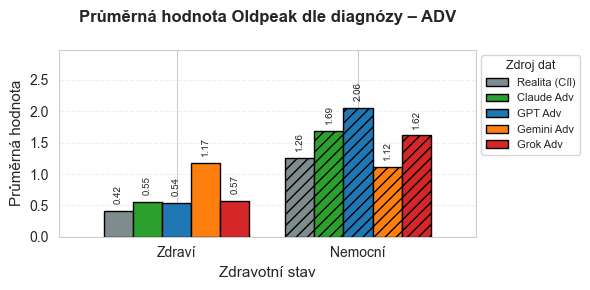

In [24]:
# graf
plt.figure(figsize=(6, 3))

plot_data = oldpeak_comp_adv.copy()
plot_data.index = ["Zdraví", "Nemocní"]

ax = plot_data.plot(
    kind="bar", 
    figsize=(6, 3), 
    color=colors, 
    width=0.8, 
    edgecolor="black",
    ax=plt.gca()
)

plt.ylim(0, plot_data.values.max() * 1.45)
plt.title("Průměrná hodnota Oldpeak dle diagnózy – ADV", fontsize=12, fontweight="bold", pad=20)
plt.ylabel("Průměrná hodnota", fontsize=11)
plt.xlabel("Zdravotní stav", fontsize=11)
plt.xticks(rotation=0, fontsize=10)
plt.yticks(fontsize=10)

plt.legend(title="Zdroj dat", fontsize=8, title_fontsize=9, loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(axis="y", linestyle="--", alpha=0.3)

for i, p in enumerate(ax.patches):
        if i % 2 == 1: 
            p.set_hatch('///')

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f'{height:.2f}', 
            (p.get_x() + p.get_width() / 2., height), 
            ha='center', va='bottom', 
            fontsize=7, 
            rotation=90, 
            xytext=(0, 5), 
            textcoords='offset points'
        )

plt.tight_layout()
plt.savefig("oldpeak_distribuce_adv.svg")
plt.show()

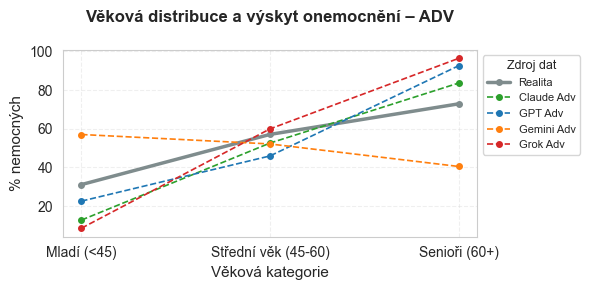

In [25]:
# nemoc X věkové skupiny ADV

def get_age_risk_adv(df, target_col):
    df_temp = df.copy()
    df_temp['age_group'] = pd.cut(df_temp['age'], bins=bins, labels=labels)
    
    is_disease = df_temp[target_col].astype(str).str.contains('1|2|3|4|Disease|Positive', case=False, na=False)
    return is_disease.groupby(df_temp['age_group'], observed=True).mean() * 100

age_risk_adv = pd.DataFrame({
    "Realita": get_age_risk_adv(df_all, 'target_text'),
    "Claude Adv":  get_age_risk_adv(df_claude_adv, 'target'),
    "GPT Adv":     get_age_risk_adv(df_gpt_adv, 'target'),
    "Gemini Adv":  get_age_risk_adv(df_gemini_adv, 'target'),
    "Grok Adv":    get_age_risk_adv(df_grok_adv, 'target')
})

plt.figure(figsize=(6, 3))

for i, col in enumerate(age_risk_adv.columns):
    is_real = (col == "Realita")
    linewidth = 2.5 if is_real else 1.2
    linestyle = '-' if is_real else '--'
    
    plt.plot(
        age_risk_comp.index, 
        age_risk_adv[col], 
        label=col, 
        color=colors[i], 
        linewidth=linewidth, 
        linestyle=linestyle, 
        marker='o', 
        markersize=4
    )

plt.title("Věková distribuce a výskyt onemocnění – ADV", fontsize=12, fontweight="bold", pad=20)
plt.ylabel("% nemocných", fontsize=11)
plt.xlabel("Věková kategorie", fontsize=11)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(True, linestyle="--", alpha=0.3)
plt.legend(title="Zdroj dat", fontsize=8, title_fontsize=9, loc='upper left', bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.savefig("vek_riziko_adv.svg")
plt.show()

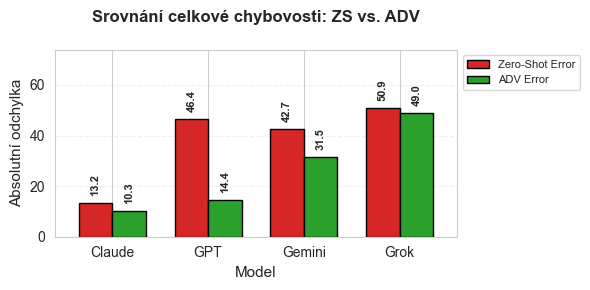

In [26]:
# Error rate

err_sex_zs = (comparison_sex_zs.drop(columns=["Realita"]).sub(comparison_sex_zs["Realita"], axis=0)).abs().sum()
err_sex_adv = (sex_comp_adv.drop(columns=["Realita"]).sub(sex_comp_adv["Realita"], axis=0)).abs().sum()

err_dis_zs = (disease_comp_zs.drop(columns=["Realita"]).sub(disease_comp_zs["Realita"], axis=0)).abs().sum()
err_dis_adv = (disease_comp_adv.drop(columns=["Realita"]).sub(disease_comp_adv["Realita"], axis=0)).abs().sum()

err_sex_adv.index = err_sex_adv.index.str.replace(" Adv", "", regex=False)
err_dis_adv.index = err_dis_adv.index.str.replace(" Adv", "", regex=False)

improvement_df = pd.DataFrame({
    "Zero-Shot Error": err_sex_zs + err_dis_zs,
    "ADV Error": err_sex_adv + err_dis_adv
})

plt.figure(figsize=(6, 3))

ax = improvement_df.plot(
    kind="bar", 
    figsize=(6, 3), 
    color=["#d62728", "#2ca02c"], 
    edgecolor="black", 
    width=0.7,
    ax=plt.gca()
)

plt.ylim(0, improvement_df.values.max() * 1.45)

plt.title("Srovnání celkové chybovosti: ZS vs. ADV", fontsize=12, fontweight="bold", pad=20)
plt.ylabel("Absolutní odchylka", fontsize=11)
plt.xlabel("Model", fontsize=11)

plt.xticks(rotation=0, fontsize=10)
plt.yticks(fontsize=10)

plt.legend(fontsize=8, loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(axis="y", linestyle="--", alpha=0.3)

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f'{height:.1f}', 
            (p.get_x() + p.get_width() / 2., height), 
            ha='center', va='bottom', 
            fontsize=8, 
            fontweight="bold",
            rotation=90,
            xytext=(0, 5), 
            textcoords='offset points'
        )

plt.tight_layout()
plt.savefig("chybovost_srovnani_zs_adv.svg")
plt.show()